In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)

In [2]:
def load_data(filepath="data/telecom_churn.csv"):
 
    df = pd.read_csv(filepath)
    return df

df = load_data()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1500 non-null   str    
 1   gender             1500 non-null   str    
 2   senior_citizen     1500 non-null   int64  
 3   tenure             1500 non-null   int64  
 4   monthly_charges    1500 non-null   float64
 5   total_charges      1500 non-null   float64
 6   contract_type      1500 non-null   str    
 7   internet_service   1500 non-null   str    
 8   num_support_calls  1500 non-null   int64  
 9   payment_method     1500 non-null   str    
 10  has_partner        1500 non-null   int64  
 11  has_dependents     1500 non-null   int64  
 12  churned            1500 non-null   int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 152.5 KB


In [3]:
print("\nSummary statistics of numerical columns:")
print(df.describe())


Summary statistics of numerical columns:
       senior_citizen       tenure  monthly_charges  total_charges  \
count     1500.000000  1500.000000      1500.000000    1500.000000   
mean         0.202000    37.063333        64.663760    2415.385033   
std          0.401626    20.710543        26.527237    1784.031684   
min          0.000000     1.000000        20.020000      28.640000   
25%          0.000000    19.000000        40.680000     975.507500   
50%          0.000000    38.000000        64.440000    2019.945000   
75%          0.000000    55.000000        88.170000    3530.507500   
max          1.000000    72.000000       109.940000    8686.960000   

       num_support_calls  has_partner  has_dependents      churned  
count        1500.000000  1500.000000     1500.000000  1500.000000  
mean            1.694667     0.511333        0.334667     0.162667  
std             1.632344     0.500038        0.472031     0.369184  
min             0.000000     0.000000        0.0000

In [4]:
print("\nSummary statistics of categorical columns:")
print(df.describe(include='O'))


Summary statistics of categorical columns:
       customer_id gender   contract_type internet_service    payment_method
count         1500   1500            1500             1500              1500
unique        1500      2               3                3                 4
top        PT-0001   Male  Month-to-month      Fiber optic  Electronic check
freq             1    771             767              674               399


C:\Users\User\AppData\Local\Temp\ipykernel_11424\2698584360.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='O'))


In [5]:
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
customer_id              str
gender                   str
senior_citizen         int64
tenure                 int64
monthly_charges      float64
total_charges        float64
contract_type            str
internet_service         str
num_support_calls      int64
payment_method           str
has_partner            int64
has_dependents         int64
churned                int64
dtype: object


In [6]:
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
customer_id          1500
gender                  2
senior_citizen          2
tenure                 72
monthly_charges      1390
total_charges        1497
contract_type           3
internet_service        3
num_support_calls       9
payment_method          4
has_partner             2
has_dependents          2
churned                 2
dtype: int64


In [7]:
print("\nValue counts for the 'Sex' column:")
print(df['gender'].value_counts())


Value counts for the 'Sex' column:
gender
Male      771
Female    729
Name: count, dtype: int64


In [8]:
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


# Split the data into Training, Validation, and Test sets

In [9]:
X = df.drop('churned', axis=1)
y = df['churned']

In [10]:
X_train_strat, X_temp_strat, y_train_strat, y_temp_strat = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val_strat, X_test_strat, y_val_strat, y_test_strat = train_test_split(X_temp_strat, y_temp_strat, test_size=0.5, random_state=42, stratify=y_temp_strat)

print("\nValue Counts for Target Variable (Stratified Split):")
print("Training set (churned):")
print(y_train_strat.value_counts(normalize=True))
print("\nValidation set (churned):")
print(y_val_strat.value_counts(normalize=True))  
print("\nTest set (churned):")
print(y_test_strat.value_counts(normalize=True)) 


Value Counts for Target Variable (Stratified Split):
Training set (churned):
churned
0    0.837778
1    0.162222
Name: proportion, dtype: float64

Validation set (churned):
churned
0    0.836667
1    0.163333
Name: proportion, dtype: float64

Test set (churned):
churned
0    0.836667
1    0.163333
Name: proportion, dtype: float64


In [11]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

class DataCleaner:
    def fit(self, X, y=None):
        pass
    
    def transform(self, X):
        return X

cross_val_scores = []

for train_index, val_index in skf.split(X, y):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    cleaner = DataCleaner()

    cleaner.fit(X_train)

    X_train_cleaned = cleaner.transform(X_train)
    X_val_cleaned = cleaner.transform(X_val)

    dummy_clf.fit(X_train_cleaned, y_train)

    score = dummy_clf.score(X_val_cleaned, y_val)
    cross_val_scores.append(score)

print("\nCross-Validation Scores:")
print(cross_val_scores)


Cross-Validation Scores:
[0.8366666666666667, 0.8366666666666667, 0.8366666666666667, 0.8366666666666667, 0.84]


In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [13]:
print(f"Training set (X_train, y_train) shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set (X_val, y_val) shape: {X_val.shape}, {y_val.shape}")
print(f"Test set (X_test, y_test) shape: {X_test.shape}, {y_test.shape}")

Training set (X_train, y_train) shape: (900, 12), (900,)
Validation set (X_val, y_val) shape: (300, 12), (300,)
Test set (X_test, y_test) shape: (300, 12), (300,)


In [14]:
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()

# Exploratory Data Analysis (EDA)

Target variable distribution (churned):
churned
0    0.837778
1    0.162222
Name: proportion, dtype: float64


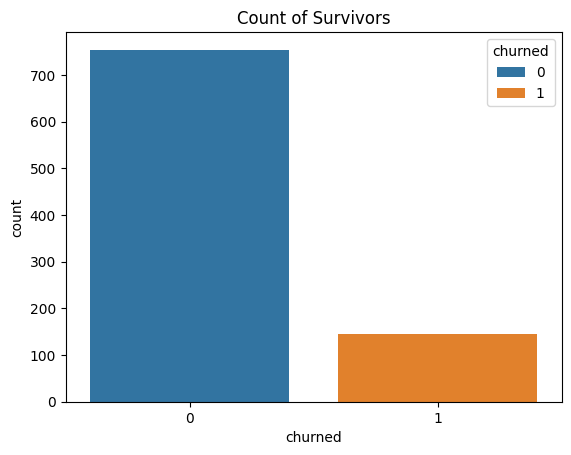

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Target variable distribution (churned):")
print(y_train.value_counts(normalize=True))
sns.countplot(x=y_train, hue=y_train)
plt.title('Count of Survivors')
plt.show()

### Assess Missing Values

In [16]:
print("\nMissing Values in Each Column:")
print(X_train.isnull().sum())


Missing Values in Each Column:
customer_id          0
gender               0
senior_citizen       0
tenure               0
monthly_charges      0
total_charges        0
contract_type        0
internet_service     0
num_support_calls    0
payment_method       0
has_partner          0
has_dependents       0
dtype: int64


### Explore relationships between features and the target variable

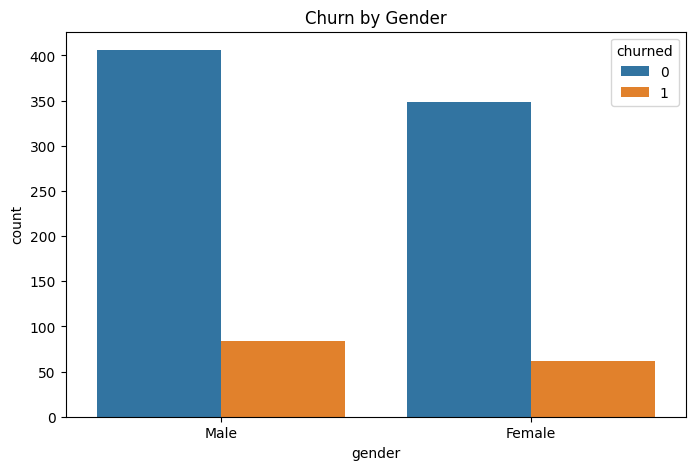

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=X_train['gender'],
    hue=y_train
)

plt.title('Churn by Gender')
plt.show()

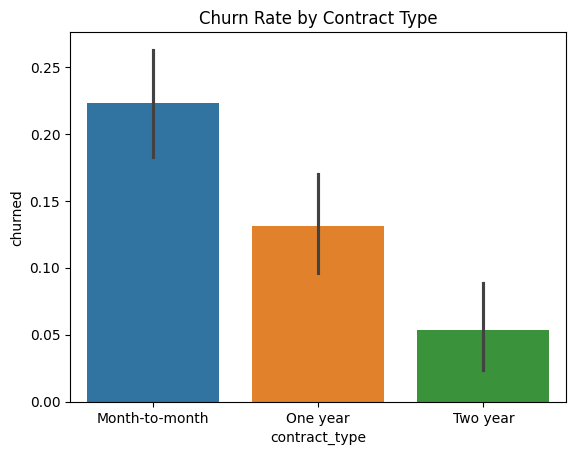

In [25]:

sns.barplot(
    x='contract_type',
    y='churned',
    hue='contract_type',
    data=df
)

plt.title('Churn Rate by Contract Type')
plt.show()

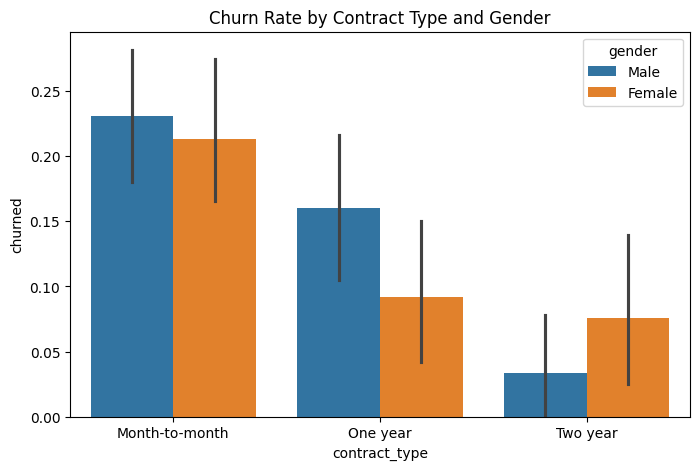

In [ ]:
# plt.figure(figsize=(8, 5))

# sns.barplot(
#     x=X_train['contract_type'],
#     y=y_train,
#     hue=X_train['gender']
# )

# plt.title('Churn Rate by Contract Type and Gender')
# plt.show()

In [ ]:
# def split_data(df, target_col, test_size=0.2, random_state=42):
#     """Split data into train and test sets with stratification.

#     Args:
#         df: DataFrame with features and target.
#         target_col: Name of the target column.
#         test_size: Fraction for test set.
#         random_state: Random seed.

#     Returns:
#         Tuple of (X_train, X_test, y_train, y_test).
#     """
#     # TODO: Separate features and target, then split with stratification
#     pass



In [ ]:
# def build_logistic_pipeline():
#     """Build a Pipeline with StandardScaler and LogisticRegression.

#     Returns:
#         sklearn Pipeline object.
#     """
#     # TODO: Create and return a Pipeline with two steps
#     pass



In [ ]:
# def build_ridge_pipeline():
#     """Build a Pipeline with StandardScaler and Ridge regression.

#     Returns:
#         sklearn Pipeline object.
#     """
#     # TODO: Create and return a Pipeline for Ridge regression
#     pass



In [ ]:
# def evaluate_classifier(pipeline, X_train, X_test, y_train, y_test):
#     """Train the pipeline and return classification metrics.

#     Args:
#         pipeline: sklearn Pipeline with a classifier.
#         X_train, X_test: Feature arrays.
#         y_train, y_test: Label arrays.

#     Returns:
#         Dictionary with keys: 'accuracy', 'precision', 'recall', 'f1'.
#     """
#     # TODO: Fit the pipeline on training data, predict on test, compute metrics
#     pass



In [ ]:
# def evaluate_regressor(pipeline, X_train, X_test, y_train, y_test):
#     """Train the pipeline and return regression metrics.

#     Args:
#         pipeline: sklearn Pipeline with a regressor.
#         X_train, X_test: Feature arrays.
#         y_train, y_test: Target arrays.

#     Returns:
#         Dictionary with keys: 'mae', 'r2'.
#     """
#     # TODO: Fit the pipeline, predict, and compute MAE and R²
#     pass



In [ ]:
# def run_cross_validation(pipeline, X_train, y_train, cv=5):
#     """Run stratified cross-validation on the pipeline.

#     Args:
#         pipeline: sklearn Pipeline.
#         X_train: Training features.
#         y_train: Training labels.
#         cv: Number of folds.

#     Returns:
#         Array of cross-validation scores.
#     """
#     # TODO: Run cross_val_score with StratifiedKFold
#     pass


# if __name__ == "__main__":
#     df = load_data()
#     if df is not None:
#         print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

#         # Select numeric features for classification
#         numeric_features = ["tenure", "monthly_charges", "total_charges",
#                            "num_support_calls", "senior_citizen",
#                            "has_partner", "has_dependents"]

#         # Classification: predict churn
#         df_cls = df[numeric_features + ["churned"]].dropna()
#         split = split_data(df_cls, "churned")
#         if split:
#             X_train, X_test, y_train, y_test = split
#             pipe = build_logistic_pipeline()
#             if pipe:
#                 metrics = evaluate_classifier(pipe, X_train, X_test, y_train, y_test)
#                 print(f"Logistic Regression: {metrics}")

#                 scores = run_cross_validation(pipe, X_train, y_train)
#                 if scores is not None:
#                     print(f"CV: {scores.mean():.3f} +/- {scores.std():.3f}")

#         # Regression: predict monthly_charges
#         df_reg = df[["tenure", "total_charges", "num_support_calls",
#                      "senior_citizen", "has_partner", "has_dependents",
#                      "monthly_charges"]].dropna()
#         split_reg = split_data(df_reg, "monthly_charges")
#         if split_reg:
#             X_tr, X_te, y_tr, y_te = split_reg
#             ridge_pipe = build_ridge_pipeline()
#             if ridge_pipe:
#                 reg_metrics = evaluate_regressor(ridge_pipe, X_tr, X_te, y_tr, y_te)
#                 print(f"Ridge Regression: {reg_metrics}")


In [ ]:
# """
# Module 5 Week A — Lab: Regression & Evaluation

# Build and evaluate logistic and linear regression models on the
# Petra Telecom customer churn dataset.

# Run: python lab_regression.py
# """

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# from sklearn.linear_model import LogisticRegression, Ridge, Lasso
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import (classification_report, confusion_matrix,
#                              ConfusionMatrixDisplay,
#                              accuracy_score, precision_score,
#                              recall_score, f1_score,
#                              mean_absolute_error, r2_score)


# def load_data(filepath="data/telecom_churn.csv"):
#     """Load the telecom churn dataset.

#     Returns:
#         DataFrame with all columns.
#     """
#     df = pd.read_csv(filepath)

#     # Basic EDA
#     print("=== Basic EDA ===")
#     print(f"Shape: {df.shape}")
#     print(f"\nMissing values:\n{df.isnull().sum()}")
#     print(f"\nChurn distribution:\n{df['churned'].value_counts()}")
#     print(f"Churn rate: {df['churned'].mean():.2%}")

#     return df


# def split_data(df, target_col, test_size=0.2, random_state=42):
#     """Split data into train and test sets with stratification.

#     Args:
#         df: DataFrame with features and target.
#         target_col: Name of the target column.
#         test_size: Fraction for test set.
#         random_state: Random seed.

#     Returns:
#         Tuple of (X_train, X_test, y_train, y_test).
#     """
#     X = df.drop(columns=[target_col])
#     y = df[target_col]

#     # Use stratify only for classification (binary/categorical target)
#     # For continuous targets like monthly_charges, stratify is not applicable
#     if y.nunique() <= 10:
#         stratify = y
#     else:
#         stratify = None

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y,
#         test_size=test_size,
#         random_state=random_state,
#         stratify=stratify
#     )

#     print(f"\n=== Split: target='{target_col}' ===")
#     print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
#     if stratify is not None:
#         print(f"Train churn rate: {y_train.mean():.2%}")
#         print(f"Test  churn rate: {y_test.mean():.2%}")

#     return X_train, X_test, y_train, y_test


# def build_logistic_pipeline():
#     """Build a Pipeline with StandardScaler and LogisticRegression.

#     Returns:
#         sklearn Pipeline object.
#     """
#     pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("classifier", LogisticRegression(
#             random_state=42,
#             max_iter=1000,
#             class_weight="balanced"
#         ))
#     ])
#     return pipeline


# def build_ridge_pipeline():
#     """Build a Pipeline with StandardScaler and Ridge regression.

#     Returns:
#         sklearn Pipeline object.
#     """
#     pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", Ridge(alpha=1.0))
#     ])
#     return pipeline


# def build_lasso_pipeline():
#     """Build a Pipeline with StandardScaler and Lasso regression.

#     Returns:
#         sklearn Pipeline object.
#     """
#     pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("regressor", Lasso(alpha=0.1))
#     ])
#     return pipeline


# def evaluate_classifier(pipeline, X_train, X_test, y_train, y_test):
#     """Train the pipeline and return classification metrics.

#     Args:
#         pipeline: sklearn Pipeline with a classifier.
#         X_train, X_test: Feature arrays.
#         y_train, y_test: Label arrays.

#     Returns:
#         Dictionary with keys: 'accuracy', 'precision', 'recall', 'f1'.
#     """
#     pipeline.fit(X_train, y_train)
#     y_pred = pipeline.predict(X_test)

#     print("\n=== Classification Report ===")
#     print(classification_report(y_test, y_pred))

#     print("=== Confusion Matrix ===")
#     cm = confusion_matrix(y_test, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#     disp.plot()
#     print(cm)

#     metrics = {
#         "accuracy":  accuracy_score(y_test, y_pred),
#         "precision": precision_score(y_test, y_pred, zero_division=0),
#         "recall":    recall_score(y_test, y_pred, zero_division=0),
#         "f1":        f1_score(y_test, y_pred, zero_division=0),
#     }
#     return metrics


# def evaluate_regressor(pipeline, X_train, X_test, y_train, y_test):
#     """Train the pipeline and return regression metrics.

#     Args:
#         pipeline: sklearn Pipeline with a regressor.
#         X_train, X_test: Feature arrays.
#         y_train, y_test: Target arrays.

#     Returns:
#         Dictionary with keys: 'mae', 'r2'.
#     """
#     pipeline.fit(X_train, y_train)
#     y_pred = pipeline.predict(X_test)

#     metrics = {
#         "mae": mean_absolute_error(y_test, y_pred),
#         "r2":  r2_score(y_test, y_pred),
#     }
#     return metrics


# def run_cross_validation(pipeline, X_train, y_train, cv=5):
#     """Run stratified cross-validation on the pipeline.

#     Args:
#         pipeline: sklearn Pipeline.
#         X_train: Training features.
#         y_train: Training labels.
#         cv: Number of folds.

#     Returns:
#         Array of cross-validation scores.
#     """
#     cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
#     scores = cross_val_score(pipeline, X_train, y_train,
#                              cv=cv_splitter, scoring="accuracy")

#     print("\n=== Cross-Validation Scores ===")
#     for i, score in enumerate(scores, 1):
#         print(f"  Fold {i}: {score:.4f}")
#     print(f"  Mean: {scores.mean():.3f} +/- {scores.std():.3f}")

#     return scores








=== Basic EDA ===
Shape: (1500, 13)

Missing values:
customer_id          0
gender               0
senior_citizen       0
tenure               0
monthly_charges      0
total_charges        0
contract_type        0
internet_service     0
num_support_calls    0
payment_method       0
has_partner          0
has_dependents       0
churned              0
dtype: int64

Churn distribution:
churned
0    1256
1     244
Name: count, dtype: int64
Churn rate: 16.27%

Loaded 1500 rows, 13 columns

CLASSIFICATION: Logistic Regression → churned

=== Split: target='churned' ===
Train size: 1200, Test size: 300
Train churn rate: 16.25%
Test  churn rate: 16.33%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       251
           1       0.23      0.51      0.31        49

    accuracy                           0.63       300
   macro avg       0.55      0.58      0.53       300
weighted avg       0.77      0.63      0.68  

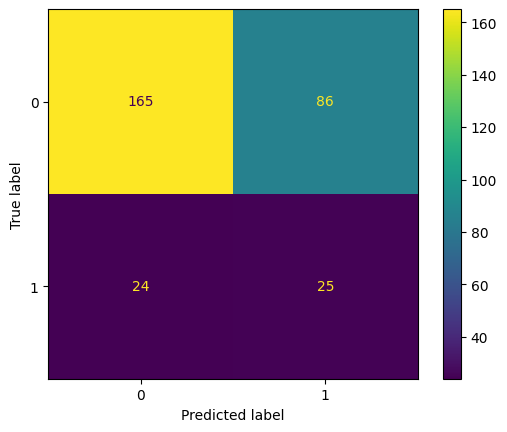

In [ ]:
# if __name__ == "__main__":
#     df = load_data()
#     if df is not None:
#         print(f"\nLoaded {len(df)} rows, {df.shape[1]} columns")

#         # Select numeric features for classification
#         numeric_features = ["tenure", "monthly_charges", "total_charges",
#                             "num_support_calls", "senior_citizen",
#                             "has_partner", "has_dependents"]

#         # ── Task 2 & 3: Classification — predict churn ────────────────────
#         print("\n" + "=" * 50)
#         print("CLASSIFICATION: Logistic Regression → churned")
#         print("=" * 50)

#         df_cls = df[numeric_features + ["churned"]].dropna()
#         split = split_data(df_cls, "churned")
#         if split:
#             X_train, X_test, y_train, y_test = split
#             pipe = build_logistic_pipeline()
#             if pipe:
#                 metrics = evaluate_classifier(pipe, X_train, X_test,
#                                               y_train, y_test)
#                 print(f"\nLogistic Regression metrics: {metrics}")

#                 # Task 6: Cross-validation
#                 scores = run_cross_validation(pipe, X_train, y_train)
#                 if scores is not None:
#                     print(f"CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")

#         # ── Task 4: Regression — predict monthly_charges (Ridge) ──────────
#         print("\n" + "=" * 50)
#         print("REGRESSION (Ridge): predict monthly_charges")
#         print("=" * 50)

#         df_reg = df[["tenure", "total_charges", "num_support_calls",
#                      "senior_citizen", "has_partner", "has_dependents",
#                      "monthly_charges"]].dropna()
#         split_reg = split_data(df_reg, "monthly_charges")
#         if split_reg:
#             X_tr, X_te, y_tr, y_te = split_reg
#             ridge_pipe = build_ridge_pipeline()
#             if ridge_pipe:
#                 reg_metrics = evaluate_regressor(ridge_pipe, X_tr, X_te,
#                                                  y_tr, y_te)
#                 print(f"\nRidge Regression metrics: {reg_metrics}")

#         # ── Task 5: Lasso comparison ───────────────────────────────────────
#         print("\n" + "=" * 50)
#         print("REGRESSION (Lasso vs Ridge): coefficient comparison")
#         print("=" * 50)

#         if split_reg:
#             lasso_pipe = build_lasso_pipeline()
#             lasso_pipe.fit(X_tr, y_tr)
#             ridge_pipe.fit(X_tr, y_tr)   # already fitted, re-fit for clarity

#             feature_names = X_tr.columns.tolist()
#             ridge_coefs = ridge_pipe.named_steps["regressor"].coef_
#             lasso_coefs = lasso_pipe.named_steps["regressor"].coef_

#             print(f"\n{'Feature':<22} {'Ridge':>10} {'Lasso':>10}")
#             print("-" * 44)
#             for feat, r, l in zip(feature_names, ridge_coefs, lasso_coefs):
#                 zeroed = " ← zeroed" if abs(l) < 1e-6 else ""
#                 print(f"{feat:<22} {r:>10.4f} {l:>10.4f}{zeroed}")